In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

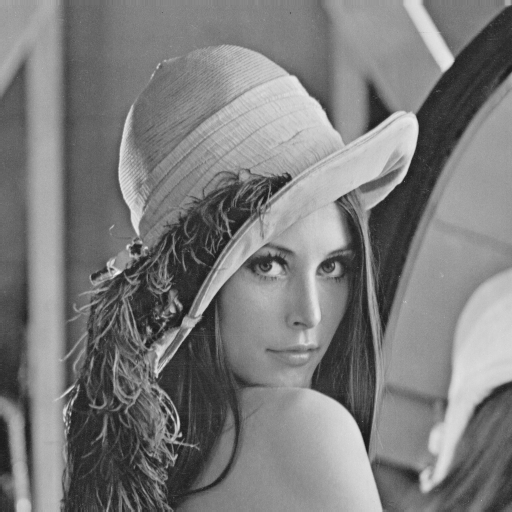

In [ ]:
#READ THE IMAGE USING PILLOW LIBRARY AND DISPLAY IT
image = Image.open("lena_gray.gif");
# image.show();
display(image);

2. Display only the top left corner of 100x100 pixels.
   Extract the top-left corner of the image (100x100 pixels) and display it using NumPy and Array Indexing.

 Image Size :  (512, 512)


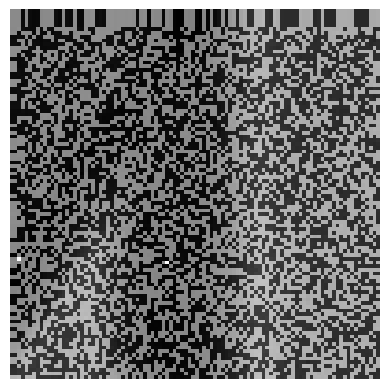

In [ ]:
print ( " Image Size : " , image . size );
#convert to NumPy array
image_array = np.array(image);
#slicling
top_left = image_array[0:100, 0:100];

plt.imshow(top_left, cmap='gray')   # use cmap only if grayscale
plt.axis('off');
plt.show()

3. Show the three color channels (R, G, B).
Separate the image into its three color channels (Red, Green, and Blue) and display them
individually, labeling each channel as R, G, and B.{Using NumPy.}

(1200, 1200, 4)


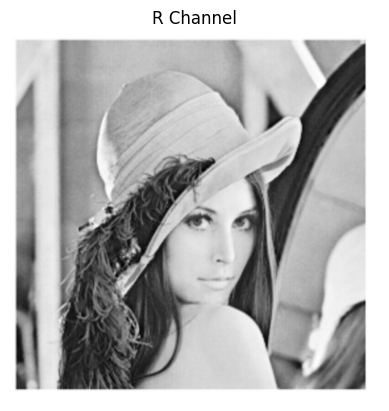

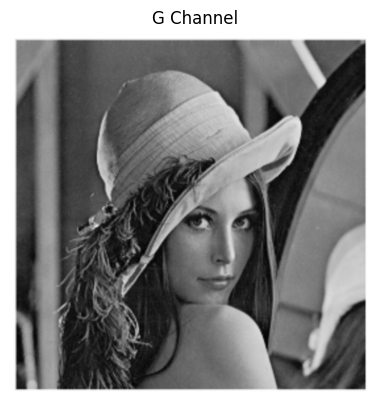

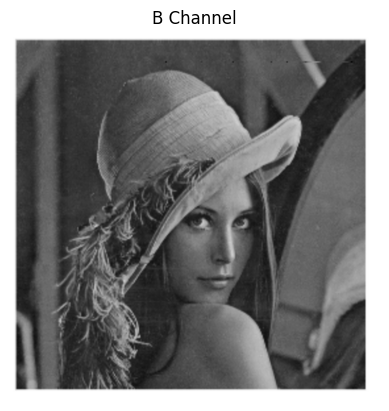

In [ ]:
# Load color image
image = Image.open("lena.png")   # replace with your color image filename
image_array = np.array(image)

print(image_array.shape)  # should be (height, width, 3)

# Extract channels using NumPy
red   = image_array[:, :, 0]
green = image_array[:, :, 1]
blue  = image_array[:, :, 2]

# Display Red channel
plt.imshow(red, cmap='gray')
plt.title("R Channel")
plt.axis('off')
plt.show()

# Display Green channel
plt.imshow(green, cmap='gray')
plt.title("G Channel")
plt.axis('off')
plt.show()

# Display Blue channel
plt.imshow(blue, cmap='gray')
plt.title("B Channel")
plt.axis('off')
plt.show()

4. Modify the top 100 × 100 pixels to a value of 210 and display the resulting image:
• Modify the pixel values of the top-left 100 × 100 region to have a value of 210 (which is a
light gray color), and then display the modified image.

In [ ]:
# Modify top-left 100x100 region
image_array = Image.open("lena_gray.gif")
image_array[0:100, 0:100] = 210

# Display full modified image
plt.imshow(image_array, cmap='gray')
plt.axis('off')
plt.show()

TypeError: 'GifImageFile' object does not support item assignment

**2.2 Exercise - 2:**

1. Load and display a grayscale image.
• Load a grayscale image using the Pillow library.
• Display the grayscale image using matplotlib.

In [4]:
import os
print(os.getcwd())

/content


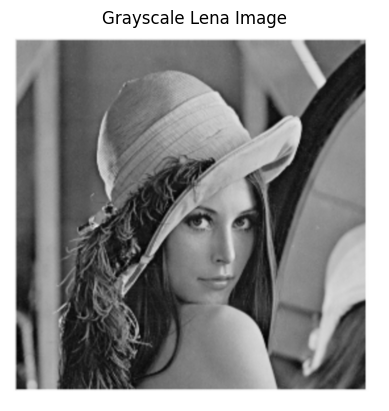

In [5]:
from PIL import Image
import matplotlib.pyplot as plt

# Load the image
img = Image.open("lena.png")

# Convert to grayscale
gray_img = img.convert("L")

# Display the grayscale image
plt.imshow(gray_img, cmap='gray')
plt.title("Grayscale Lena Image")
plt.axis("off")
plt.show()

2. Extract and display the middle section of the image (150 pixels).
• Extract a 150 pixel section from the center of the image using NumPy array slicing.
• Display this cropped image using matplotlib.

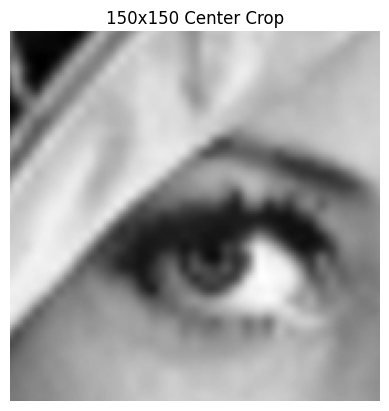

In [6]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Load image
img = Image.open("/content/lena.png")

# Convert to grayscale
gray_img = img.convert("L")

# Convert image to NumPy array
img_array = np.array(gray_img)

# Get image dimensions
h, w = img_array.shape

# Find center
center_x = w // 2
center_y = h // 2

# Crop 150x150 middle section
cropped = img_array[center_y-75:center_y+75, center_x-75:center_x+75]

# Display cropped image
plt.imshow(cropped, cmap='gray')
plt.title("150x150 Center Crop")
plt.axis("off")
plt.show()

3. Apply a simple threshold to the image (e.g., set all pixel values below 100 to 0).
• Apply a threshold to the grayscale image: set all pixel values below 100 to 0, and all values
above 100 to 255 (creating a binary image).

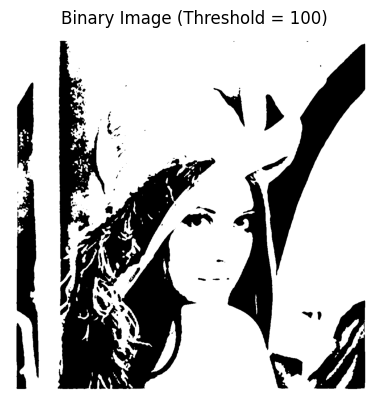

In [7]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Load image
img = Image.open("/content/lena.png")

# Convert to grayscale
gray_img = img.convert("L")

# Convert to NumPy array
img_array = np.array(gray_img)

# Apply threshold
binary_img = np.where(img_array < 100, 0, 255)

# Display result
plt.imshow(binary_img, cmap='gray')
plt.title("Binary Image (Threshold = 100)")
plt.axis("off")
plt.show()

4. Rotate the image 90 degrees clockwise and display the result.
• Rotate the image by 90 degrees clockwise using the Pillow rotate method or by manipulating
the image array.
• Display the rotated image using matplotlib.

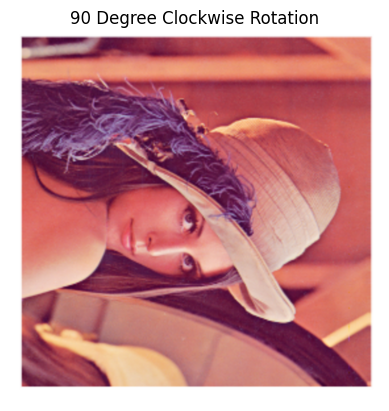

In [8]:
from PIL import Image
import matplotlib.pyplot as plt

# Load image
img = Image.open("/content/lena.png")

# Rotate 90 degrees clockwise
rotated_img = img.rotate(-90)

# Display image
plt.imshow(rotated_img)
plt.title("90 Degree Clockwise Rotation")
plt.axis("off")
plt.show()

5. Convert the grayscale image to an RGB image.
• Convert the grayscale image into an RGB image where the grayscale values are replicated
across all three channels (R, G, and B).
• Display the converted RGB image using matplotlib.

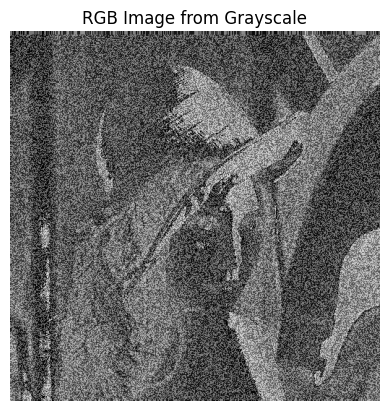

In [13]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load grayscale image
img = Image.open("/content/lena_gray.gif")

# Convert to NumPy array
gray_array = np.array(img)

# Replicate grayscale values into 3 channels
rgb_image = np.stack((gray_array, gray_array, gray_array), axis=-1)

# Display RGB image
plt.imshow(rgb_image)
plt.title("RGB Image from Grayscale")
plt.axis("off")
plt.show()

**3 Image Compression and Decompression using PCA.**
In this exercise, build a PCA from scratch using explained variance method for image compression task.
You are expected to compute the necessary matrices from the scratch. Dataset: Use image of your
choice.

1. Load and Prepare Data:
• Fetch an image of you choice.{If colour convert to grayscale}
• Center the dataset - Standaridze the Data.
• Calculate the covaraince matrix of the Standaridze data.

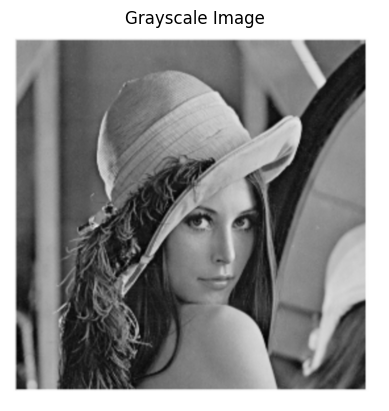

Shape of image matrix: (1200, 1200)
Shape of covariance matrix: (1200, 1200)


In [14]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = Image.open("/content/lena.png")

# Convert to grayscale if needed
gray_img = img.convert("L")

# Convert to NumPy array
X = np.array(gray_img, dtype=float)

# Display the grayscale image
plt.imshow(X, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

# Center / Standardize the data (subtract mean)
mean = np.mean(X, axis=0)
X_centered = X - mean

# Calculate covariance matrix
cov_matrix = np.cov(X_centered, rowvar=False)

print("Shape of image matrix:", X.shape)
print("Shape of covariance matrix:", cov_matrix.shape)

2. Eigen Decomposition and Identifying Principal Components:
• Compute Eigen Values and Eigen Vectors.
• Sort the eigenvalues in descending order and choose the top k eigenvectors corresponding to
the highest eigenvalues.
• Identify the Principal Components with the help of cumulative Sum plot.

Top 10 Eigenvalues:
 [1151073.12084499  431927.87818638  251995.53899767  175792.46171579
  137004.52771251  115085.67857611   84096.71403361   61349.17987911
   44664.82191499   38615.28461288]
Shape of top k eigenvectors: (1200, 50)


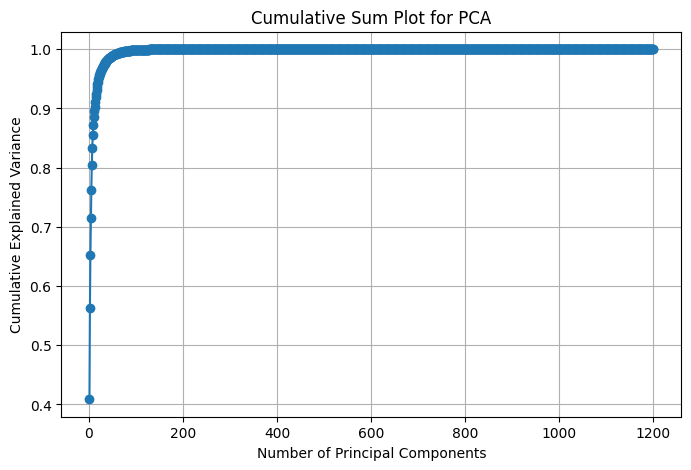

In [15]:
import numpy as np
import matplotlib.pyplot as plt

#  Eigen decomposition of covariance matrix
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Convert to real values in case of tiny imaginary parts from computation
eigenvalues = np.real(eigenvalues)
eigenvectors = np.real(eigenvectors)

#  Sort eigenvalues and eigenvectors in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

#  Explained variance ratio
explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)

#  Cumulative explained variance
cumulative_variance = np.cumsum(explained_variance_ratio)

#  Choose top k eigenvectors
k = 50   # change this value as needed
top_k_eigenvectors = sorted_eigenvectors[:, :k]

print("Top 10 Eigenvalues:\n", sorted_eigenvalues[:10])
print("Shape of top k eigenvectors:", top_k_eigenvectors.shape)

#  Plot cumulative explained variance
plt.figure(figsize=(8,5))
plt.plot(np.arange(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Sum Plot for PCA")
plt.grid(True)
plt.show()

3. Reconstruction and Experiment:

• Reconstruction: Transform the original data by multiplying it with the selected eigenvec-
tors(PCs) to obtain a lower-dimensional representation.

• Experiments: Pick Four different combination of principal components with various ex-
plained variance value and compare the result.

• Display the Results and Evaluate.

Selected k values for each variance level:
70% variance --> k = 4
85% variance --> k = 8
95% variance --> k = 21
99% variance --> k = 52


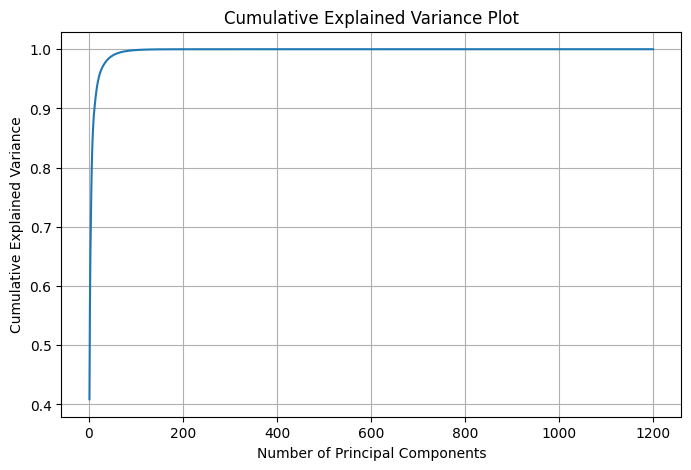

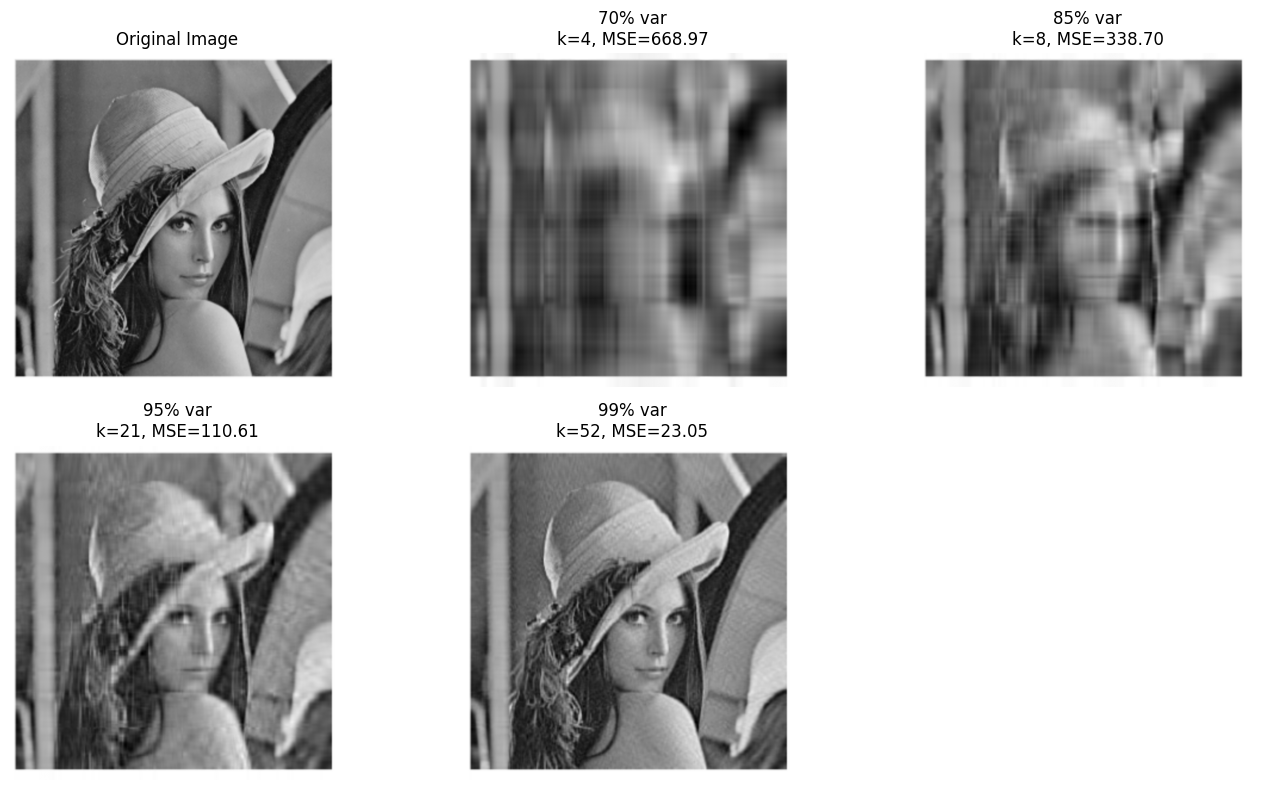

In [16]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


# 1. Load image and prepare data

img = Image.open("/content/lena.png").convert("L")
X = np.array(img, dtype=np.float64)

# Mean centering
mean = np.mean(X, axis=0)
X_centered = X - mean

# Covariance matrix
cov_matrix = np.cov(X_centered, rowvar=False)


# 2. Eigen decomposition

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Remove tiny imaginary parts if any
eigenvalues = np.real(eigenvalues)
eigenvectors = np.real(eigenvectors)

# Sort in descending order
sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

# Explained variance
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)


# 3. Choose 4 variance levels

variance_levels = [0.70, 0.85, 0.95, 0.99]
k_values = []

for v in variance_levels:
    k = np.argmax(cumulative_variance >= v) + 1
    k_values.append(k)

print("Selected k values for each variance level:")
for v, k in zip(variance_levels, k_values):
    print(f"{int(v*100)}% variance --> k = {k}")


# 4. Reconstruction function

def reconstruct_image(X_centered, eigenvectors, mean, k):
    W_k = eigenvectors[:, :k]                # top k principal components
    Z = np.dot(X_centered, W_k)              # lower-dimensional representation
    X_reconstructed = np.dot(Z, W_k.T) + mean
    return Z, X_reconstructed


# 5. Run experiments

reconstructed_images = []
mse_values = []

for k in k_values:
    Z, X_rec = reconstruct_image(X_centered, eigenvectors, mean, k)

    # Clip values to valid image range
    X_rec = np.clip(X_rec, 0, 255)

    reconstructed_images.append(X_rec)

    # Mean Squared Error
    mse = np.mean((X - X_rec) ** 2)
    mse_values.append(mse)


# 6. Display cumulative variance plot

plt.figure(figsize=(8,5))
plt.plot(np.arange(1, len(cumulative_variance)+1), cumulative_variance)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance Plot")
plt.grid(True)
plt.show()


# 7. Display original + reconstructed images

plt.figure(figsize=(14, 8))

plt.subplot(2, 3, 1)
plt.imshow(X, cmap='gray')
plt.title("Original Image")
plt.axis("off")

for i in range(4):
    plt.subplot(2, 3, i + 2)
    plt.imshow(reconstructed_images[i], cmap='gray')
    plt.title(f"{int(variance_levels[i]*100)}% var\nk={k_values[i]}, MSE={mse_values[i]:.2f}")
    plt.axis("off")

plt.tight_layout()
plt.show()